In [52]:
#Import all libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, roc_curve, auc)
import warnings
warnings.filterwarnings('ignore')

In [53]:
#Load the dataset
df = pd.read_csv('../data/student_performance.csv')

print("Shape of dataset:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape of dataset: (2392, 15)

First 5 rows:


,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0


In [54]:
#Explore the data
print("Column Names")
print(df.columns.tolist())

print("\nData Types")
print(df.dtypes)

print("\nMissing Values")
print(df.isnull().sum())

print("\nBasic Statistics")
df.describe()

Column Names
['StudentID', 'Age', 'Gender', 'Ethnicity', 'ParentalEducation', 'StudyTimeWeekly', 'Absences', 'Tutoring', 'ParentalSupport', 'Extracurricular', 'Sports', 'Music', 'Volunteering', 'GPA', 'GradeClass']

Data Types
StudentID              int64
Age                    int64
Gender                 int64
Ethnicity              int64
ParentalEducation      int64
StudyTimeWeekly      float64
Absences               int64
Tutoring               int64
ParentalSupport        int64
Extracurricular        int64
Sports                 int64
Music                  int64
Volunteering           int64
GPA                  float64
GradeClass           float64
dtype: object

Missing Values
StudentID            0
Age                  0
Gender               0
Ethnicity            0
ParentalEducation    0
StudyTimeWeekly      0
Absences             0
Tutoring             0
ParentalSupport      0
Extracurricular      0
Sports               0
Music                0
Volunteering         0
GPA      

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
count,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000
mean,2196.500000,16.468645,0.510870,0.877508,1.746237,9.771992,14.541388,0.301421,2.122074,0.383361,0.303512,0.196906,0.157191,1.906186,2.983696
std,690.655244,1.123798,0.499986,1.028476,1.000411,5.652774,8.467417,0.458971,1.122813,0.486307,0.459870,0.397744,0.364057,0.915156,1.233908
min,1001.000000,15.000000,0.000000,0.000000,0.000000,0.001057,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1598.750000,15.000000,0.000000,0.000000,1.000000,5.043079,7.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.174803,2.000000
50%,2196.500000,16.000000,1.000000,0.000000,2.000000,9.705363,15.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,1.893393,4.000000
75%,2794.250000,17.000000,1.000000,2.000000,2.000000,14.408410,22.000000,1.000000,3.000000,1.000000,1.000000,0.000000,0.000000,2.622216,4.000000
max,3392.000000,18.000000,1.000000,3.000000,4.000000,19.978094,29.000000,1.000000,4.000000,1.000000,1.000000,1.000000,1.000000,4.000000,4.000000


In [55]:
#Check target column values
print("GradeClass unique values:", df['GradeClass'].unique())
print("\nValue counts:")
print(df['GradeClass'].value_counts())

GradeClass unique values: [2. 1. 4. 3. 0.]

Value counts:
GradeClass
4.0    1211
3.0     414
2.0     391
1.0     269
0.0     107
Name: count, dtype: int64


In [56]:
#Drop StudentID and remap target to 3 classes
df = df.drop(columns=['StudentID'])

# Remap GradeClass: 0,1 = High | 2 = Medium | 3,4 = Low
def map_grade(g):
    if g in [0, 1]:
        return 'High'
    elif g == 2:
        return 'Medium'
    else:
        return 'Low'

df['PerformanceLabel'] = df['GradeClass'].apply(map_grade)
df = df.drop(columns=['GradeClass'])

print("New target column value counts:")
print(df['PerformanceLabel'].value_counts())

New target column value counts:
PerformanceLabel
Low       1625
Medium     391
High       376
Name: count, dtype: int64


In [57]:
#Encode categorical columns
le = LabelEncoder()

categorical_cols = ['Gender', 'Ethnicity', 'ParentalEducation', 
                    'Tutoring', 'ParentalSupport']

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

# Encode target label
df['PerformanceLabel'] = le.fit_transform(df['PerformanceLabel'])
# After encoding: High=0, Low=1, Medium=2 (alphabetical) — we'll note this

print("✅ Encoding done!")
print(df.head())

✅ Encoding done!
   Age  Gender  Ethnicity  ParentalEducation  StudyTimeWeekly  Absences  \
0   17       1          0                  2        19.833723         7   
1   18       0          0                  1        15.408756         0   
2   15       0          2                  3         4.210570        26   
3   17       1          0                  3        10.028829        14   
4   17       1          0                  2         4.672495        17   

   Tutoring  ParentalSupport  Extracurricular  Sports  Music  Volunteering  \
0         1                2                0       0      1             0   
1         0                1                0       0      0             0   
2         0                2                0       0      0             0   
3         0                3                1       0      0             0   
4         1                3                0       0      0             0   

        GPA  PerformanceLabel  
0  2.929196                 2  

In [58]:
#Feature scaling and train/test split
X = df.drop(columns=['PerformanceLabel'])
y = df['PerformanceLabel']

# Scale all features to same range
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print("✅ Data split complete!")
print(f"Training samples : {X_train.shape[0]}")
print(f"Testing samples  : {X_test.shape[0]}")

✅ Data split complete!
Training samples : 1913
Testing samples  : 479


In [59]:
#Train Logistic Regression model
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    solver='lbfgs',             # best solver for multiclass
    max_iter=1000,              # enough iterations to converge
    class_weight='balanced',    # handles class imbalance automatically
    random_state=42
)

model.fit(X_train, y_train)

print("✅ Model trained successfully!")
print(f"Training Accuracy: {model.score(X_train, y_train)*100:.2f}%")

✅ Model trained successfully!
Training Accuracy: 77.52%


In [60]:
#Evaluate the model
y_pred = model.predict(X_test)

# Overall accuracy
acc = accuracy_score(y_test, y_pred)
print(f"✅ Test Accuracy: {acc*100:.2f}%\n")

# Detailed report
# Label mapping: 0=High, 1=Low, 2=Medium
print("=== Classification Report ===")
print(classification_report(y_test, y_pred, 
      target_names=['High', 'Low', 'Medium']))

✅ Test Accuracy: 79.33%

=== Classification Report ===
              precision    recall  f1-score   support

        High       0.70      0.69      0.70        75
         Low       0.95      0.83      0.89       326
      Medium       0.48      0.73      0.58        78

    accuracy                           0.79       479
   macro avg       0.71      0.75      0.72       479
weighted avg       0.83      0.79      0.81       479



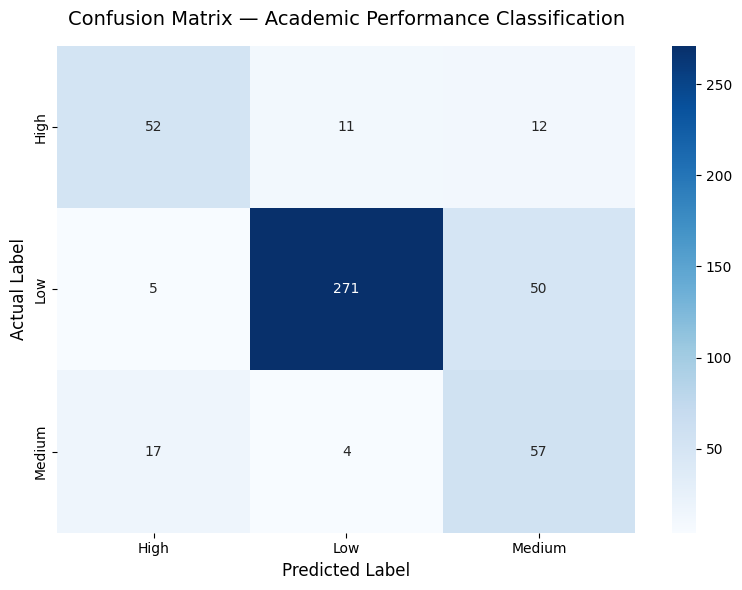

✅ Confusion matrix saved!


In [61]:
#Confusion Matrix
plt.figure(figsize=(8, 6))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['High', 'Low', 'Medium'],
            yticklabels=['High', 'Low', 'Medium'])

plt.title('Confusion Matrix — Academic Performance Classification', 
          fontsize=14, pad=15)
plt.ylabel('Actual Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig('../notebooks/confusion_matrix.png', dpi=150)
plt.show()

print("✅ Confusion matrix saved!")

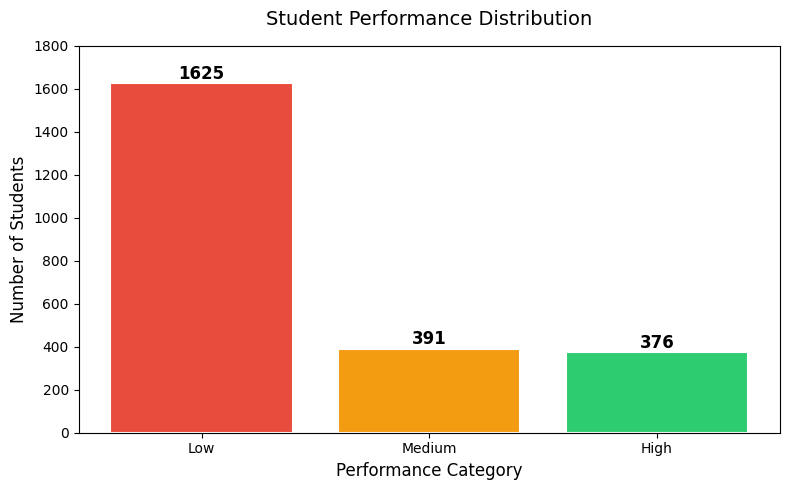

✅ Distribution plot saved!


In [62]:
#Class Distribution Plot
plt.figure(figsize=(8, 5))

labels = ['Low', 'Medium', 'High']
counts = [1625, 391, 376]
colors = ['#e74c3c', '#f39c12', '#2ecc71']

bars = plt.bar(labels, counts, color=colors, edgecolor='white', linewidth=1.5)

for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, 
             bar.get_height() + 20, 
             str(count), ha='center', fontsize=12, fontweight='bold')

plt.title('Student Performance Distribution', fontsize=14, pad=15)
plt.xlabel('Performance Category', fontsize=12)
plt.ylabel('Number of Students', fontsize=12)
plt.ylim(0, 1800)
plt.tight_layout()
plt.savefig('../notebooks/class_distribution.png', dpi=150)
plt.show()
print("✅ Distribution plot saved!")

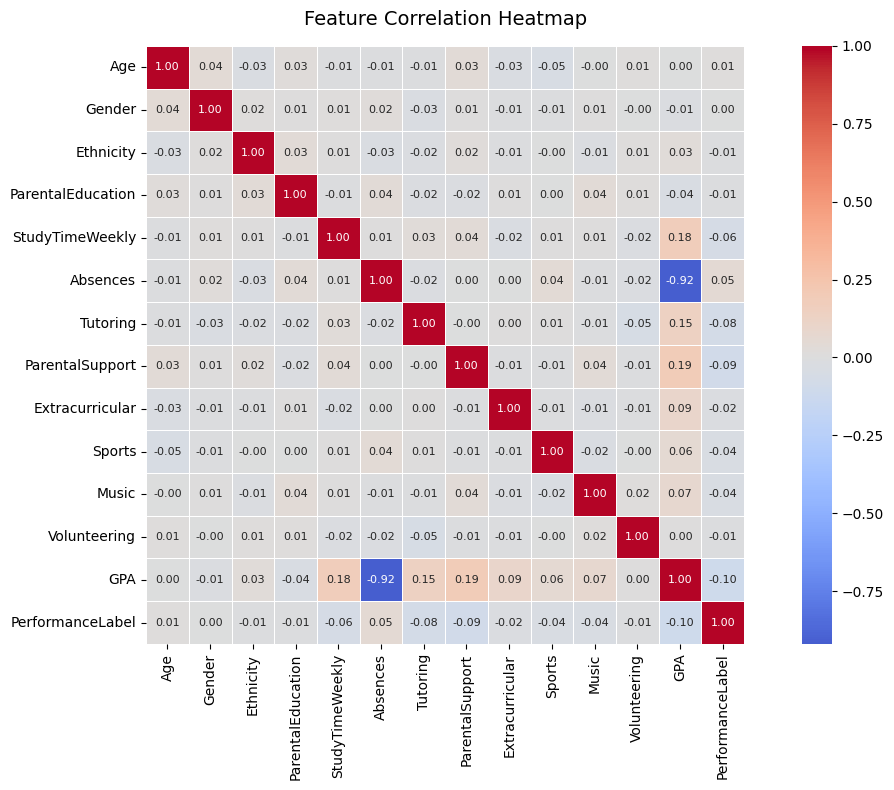

✅ Correlation heatmap saved!


In [63]:
#Correlation Heatmap
plt.figure(figsize=(12, 8))

corr = df.corr()
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5,
            annot_kws={'size': 8})

plt.title('Feature Correlation Heatmap', fontsize=14, pad=15)
plt.tight_layout()
plt.savefig('../notebooks/correlation_heatmap.png', dpi=150)
plt.show()
print("✅ Correlation heatmap saved!")

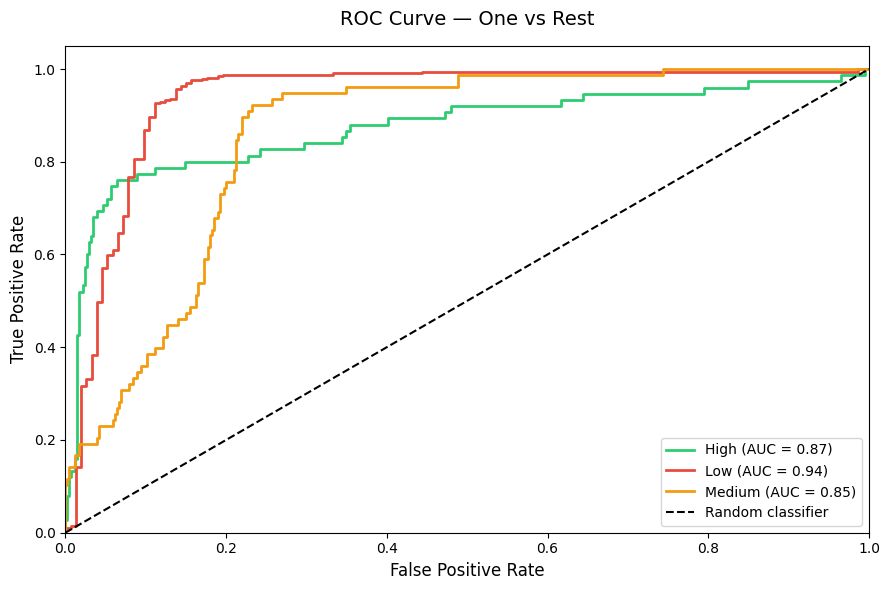

✅ ROC curve saved!


In [64]:
#ROC Curve (one vs rest for each class)
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier

# Binarize for ROC
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
class_names = ['High', 'Low', 'Medium']
colors_roc = ['#2ecc71', '#e74c3c', '#f39c12']

ovr_model = OneVsRestClassifier(LogisticRegression(
    solver='lbfgs', max_iter=1000, 
    class_weight='balanced', random_state=42))
ovr_model.fit(X_train, y_train)
y_score = ovr_model.predict_proba(X_test)

plt.figure(figsize=(9, 6))
for i, (name, color) in enumerate(zip(class_names, colors_roc)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'{name} (AUC = {roc_auc:.2f})')

plt.plot([0,1], [0,1], 'k--', lw=1.5, label='Random classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve — One vs Rest', fontsize=14, pad=15)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../notebooks/roc_curve.png', dpi=150)
plt.show()
print("✅ ROC curve saved!")

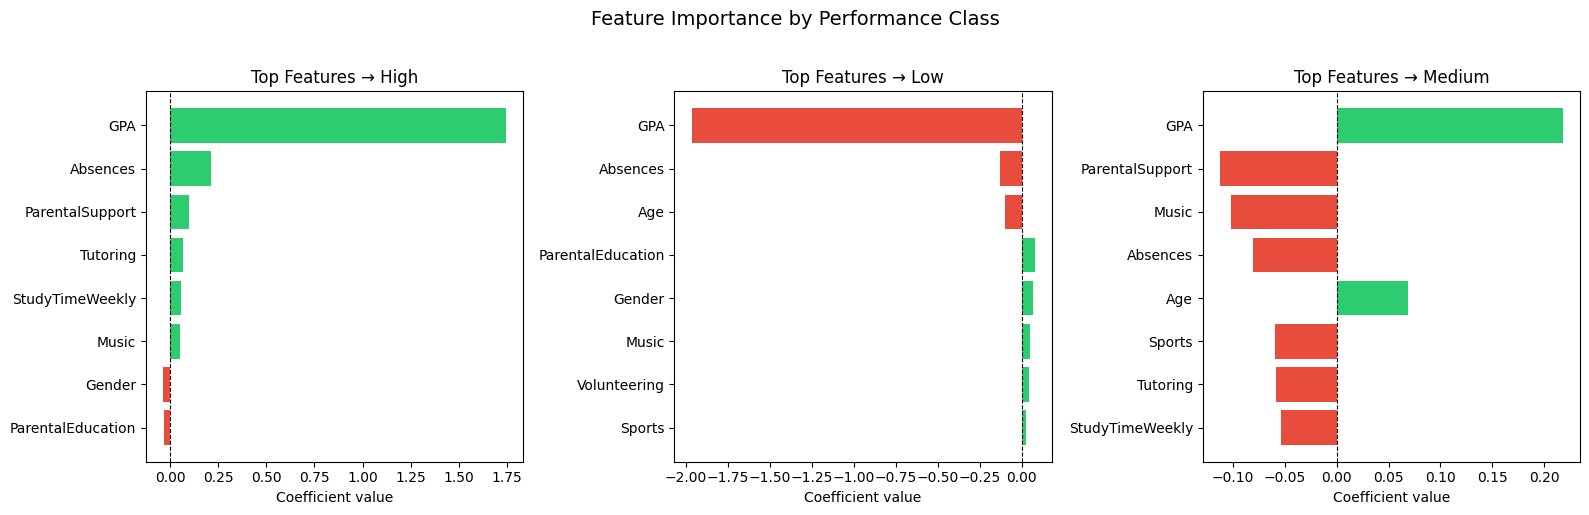

✅ Feature importance saved!


In [65]:
#Feature Importance (model coefficients)
feature_names = df.drop(columns=['PerformanceLabel']).columns
class_names = ['High', 'Low', 'Medium']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, (ax, cls) in enumerate(zip(axes, class_names)):
    coefs = model.coef_[i]
    sorted_idx = np.argsort(np.abs(coefs))[::-1][:8]
    top_features = feature_names[sorted_idx]
    top_coefs = coefs[sorted_idx]
    colors_bar = ['#2ecc71' if c > 0 else '#e74c3c' for c in top_coefs]
    
    ax.barh(top_features[::-1], top_coefs[::-1], color=colors_bar[::-1])
    ax.set_title(f'Top Features → {cls}', fontsize=12)
    ax.set_xlabel('Coefficient value')
    ax.axvline(x=0, color='black', linewidth=0.8, linestyle='--')

plt.suptitle('Feature Importance by Performance Class', 
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../notebooks/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Feature importance saved!")

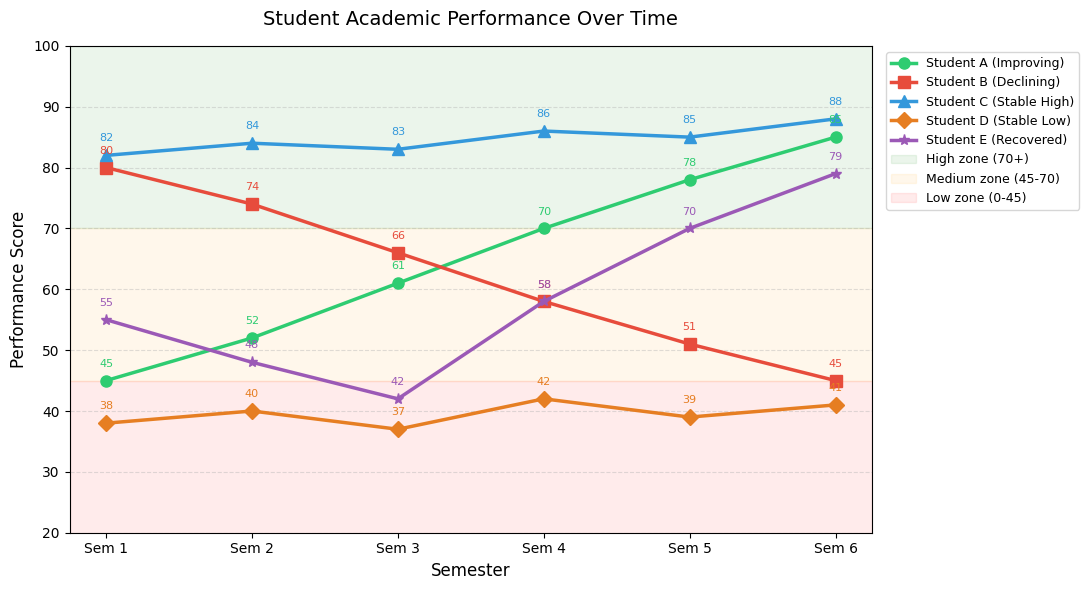

✅ Performance over time graph saved!


In [66]:
#Student Performance Over Time (Semester-wise trend)
np.random.seed(42)

semesters = ['Sem 1', 'Sem 2', 'Sem 3', 'Sem 4', 'Sem 5', 'Sem 6']

# Simulate 5 student trajectories (realistic patterns)
students = {
    'Student A (Improving)':   [45, 52, 61, 70, 78, 85],
    'Student B (Declining)':   [80, 74, 66, 58, 51, 45],
    'Student C (Stable High)': [82, 84, 83, 86, 85, 88],
    'Student D (Stable Low)':  [38, 40, 37, 42, 39, 41],
    'Student E (Recovered)':   [55, 48, 42, 58, 70, 79],
}

colors_line = ['#2ecc71', '#e74c3c', '#3498db', '#e67e22', '#9b59b6']
markers = ['o', 's', '^', 'D', '*']

plt.figure(figsize=(11, 6))

for (name, scores), color, marker in zip(students.items(), 
                                          colors_line, markers):
    plt.plot(semesters, scores, 
             color=color, marker=marker,
             linewidth=2.5, markersize=8, label=name)
    # Add score labels on each point
    for i, score in enumerate(scores):
        plt.annotate(str(score), 
                    (semesters[i], score),
                    textcoords="offset points",
                    xytext=(0, 10),
                    ha='center', fontsize=8, color=color)

# Performance zone bands
plt.axhspan(70, 100, alpha=0.08, color='green', label='High zone (70+)')
plt.axhspan(45, 70,  alpha=0.08, color='orange', label='Medium zone (45-70)')
plt.axhspan(0,  45,  alpha=0.08, color='red',    label='Low zone (0-45)')

plt.title('Student Academic Performance Over Time', fontsize=14, pad=15)
plt.xlabel('Semester', fontsize=12)
plt.ylabel('Performance Score', fontsize=12)
plt.ylim(20, 100)
plt.legend(loc='upper left', fontsize=9, bbox_to_anchor=(1.01, 1))
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('../notebooks/performance_over_time.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Performance over time graph saved!")

In [67]:
#Save the trained model
import pickle

# Save model
with open('../model.pkl', 'wb') as f:
    pickle.dump(model, f)

# Save scaler (needed to scale inputs when predicting new students)
with open('../scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("✅ Model saved as model.pkl")
print("✅ Scaler saved as scaler.pkl")
print("\nYour project folder now contains:")
print("  📊 notebooks/analysis.ipynb        - full ML notebook")
print("  📈 notebooks/confusion_matrix.png  - evaluation plot")
print("  📈 notebooks/class_distribution.png")
print("  📈 notebooks/correlation_heatmap.png")
print("  📈 notebooks/roc_curve.png")
print("  📈 notebooks/feature_importance.png")
print("  📈 notebooks/performance_over_time.png")
print("  🤖 model.pkl                        - trained model")
print("  ⚖️  scaler.pkl                       - data scaler")

✅ Model saved as model.pkl
✅ Scaler saved as scaler.pkl

Your project folder now contains:
  📊 notebooks/analysis.ipynb        - full ML notebook
  📈 notebooks/confusion_matrix.png  - evaluation plot
  📈 notebooks/class_distribution.png
  📈 notebooks/correlation_heatmap.png
  📈 notebooks/roc_curve.png
  📈 notebooks/feature_importance.png
  📈 notebooks/performance_over_time.png
  🤖 model.pkl                        - trained model
  ⚖️  scaler.pkl                       - data scaler


In [68]:
#Verify file sizes
import os

# Check both possible locations
paths_to_check = [
    '../model.pkl',
    '../scaler.pkl',
    'model.pkl',
    'scaler.pkl',
]

for p in paths_to_check:
    if os.path.exists(p):
        size = os.path.getsize(p)
        print(f"✅ Found: {p}  →  {size} bytes")
    else:
        print(f"❌ Not found: {p}")

✅ Found: ../model.pkl  →  1081 bytes
✅ Found: ../scaler.pkl  →  999 bytes
❌ Not found: model.pkl
❌ Not found: scaler.pkl


In [ ]:
#Find best model accuracy using GridSearchCV
from sklearn.model_selection import GridSearchCV

params = {
    'C':        [0.01, 0.1, 0.5, 1, 5, 10],
    'solver':   ['lbfgs', 'saga', 'newton-cg'],
    'max_iter': [500, 1000, 2000]
}

grid = GridSearchCV(
    LogisticRegression(class_weight='balanced',
                       random_state=42),
    params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
print("Best CV accuracy:", round(grid.best_score_ * 100, 2), "%")

model = grid.best_estimator_

y_pred = model.predict(X_test)
print("Test accuracy   :", round(accuracy_score(y_test, y_pred) * 100, 2), "%")
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred,
      target_names=['High', 'Low', 'Medium']))

Best parameters: {'C': 1, 'max_iter': 500, 'solver': 'lbfgs'}
Best CV accuracy: 76.84 %
Test accuracy   : 79.33 %

=== Classification Report ===
              precision    recall  f1-score   support

        High       0.70      0.69      0.70        75
         Low       0.95      0.83      0.89       326
      Medium       0.48      0.73      0.58        78

    accuracy                           0.79       479
   macro avg       0.71      0.75      0.72       479
weighted avg       0.83      0.79      0.81       479



In [70]:
# Save updated model
import pickle
import os

save_path = os.path.dirname(os.getcwd())
with open(os.path.join(save_path, 'model.pkl'), 'wb') as f:
    pickle.dump(model, f)

print("✅ Improved model saved!")

✅ Improved model saved!
